**Importing Necessary Libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Importing CSV Files**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
a = pd.read_csv("/content/drive/MyDrive/Diwali Sales Data.csv",encoding="unicode_escape")

**Checking The Dataset**

In [ ]:
a.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [ ]:
a.shape

(11251, 15)

In [ ]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


**Drop the blank/unrealted Columns**

In [ ]:
a.drop(["Status","unnamed1"],axis = 1, inplace= True)

In [ ]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


**Check for the Null Values**

In [ ]:
a.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


**Drop the Null Vlues**

In [ ]:
a.dropna(inplace = True)

**Change the DataType of the Column Amount**

In [ ]:
a['Amount'] = a['Amount'].astype('int')

In [ ]:
a["Amount"]

,Amount
0,23952
1,23934
2,23924
3,23912
4,23877
...,...
11246,370
11247,367
11248,213
11249,206


**Renameing the Column from "Marital_Status" to "Shadi"**

In [ ]:
a.rename(columns={"Marital_Status":"Shadi"}, inplace=True)

**Describing the Table for Mean, Mode, Median, Standard Deviation etc.**

In [ ]:
a.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,11239.0,1.003004e+06,1716.038826,1000001.0,1001491.5,1003064.0,1004426.5,1006040.0
Age,11239.0,3.541036e+01,12.753866,12.0,27.0,33.0,43.0,92.0
Shadi,11239.0,4.200552e-01,0.493589,0.0,0.0,0.0,1.0,1.0
Orders,11239.0,2.489634e+00,1.114967,1.0,2.0,2.0,3.0,4.0
Amount,11239.0,9.453611e+03,5222.355168,188.0,5443.0,8109.0,12675.0,23952.0


**Describing Some Specific Columns**

In [ ]:
a[["Age","Orders","Amount"]].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


#**Exploratory Data Analysis**

**Gender**

#**Plotting a Bar Chart for Gender and it's Count**

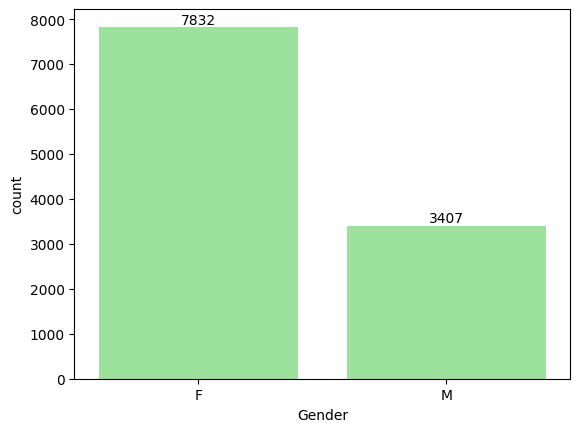

In [ ]:
ax = sns.countplot(x = 'Gender', data = a, color='lightgreen')
for bars in ax.containers:
  ax.bar_label(bars)

#**Plotting a Bar Chart for Gender vs Total Amount**

<Axes: xlabel='Gender', ylabel='Amount'>

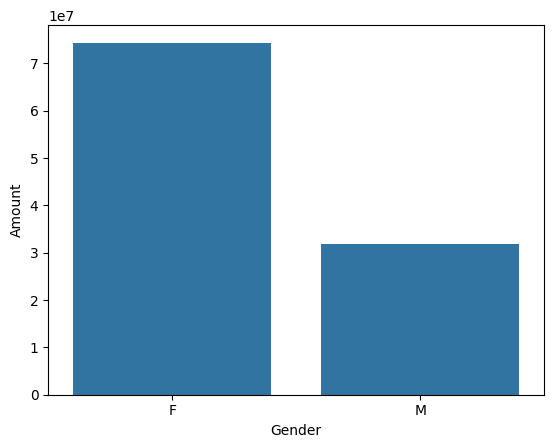

In [ ]:
ss = a.groupby(['Gender'], as_index = False)["Amount"].sum().sort_values(by = "Amount", ascending = False)
sns.barplot(x = "Gender", y = "Amount", data = ss)


From the above graph, we can see that most of the buyers are females and even the purchasing power of females are greater than men.

**Age**

/tmp/ipykernel_5710/4147391598.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:salmon'` for the same effect.

  ax = sns.countplot(data = a, x = 'Age Group', color = 'salmon', hue = 'Gender')


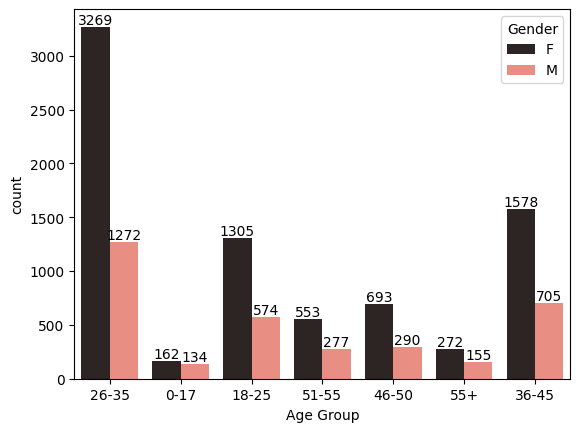

In [ ]:
ax = sns.countplot(data = a, x = 'Age Group', color = 'salmon', hue = 'Gender')
for bars in ax.containers:
  ax.bar_label(bars)

**Total Amount vs Age Group**

<Axes: xlabel='Age Group', ylabel='Amount'>

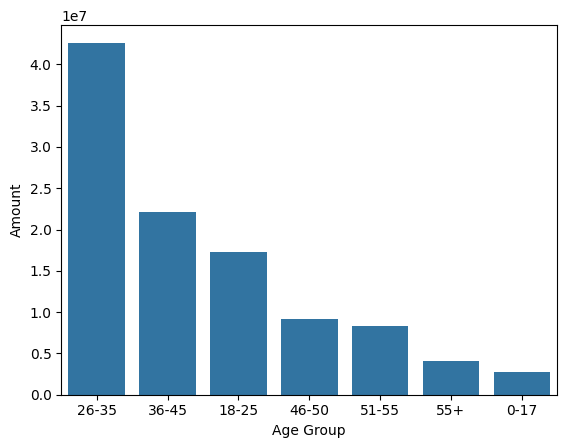

In [ ]:
sales_age = a.groupby(['Age Group'],as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.barplot(x = 'Age Group',y = 'Amount',data = sales_age)

**From the above graph, we can see that most of the byiers are from the Age Group of 26-36 years.**

**States**

**Total numbers of order from the top 10 states.**

<Axes: xlabel='State', ylabel='Orders'>

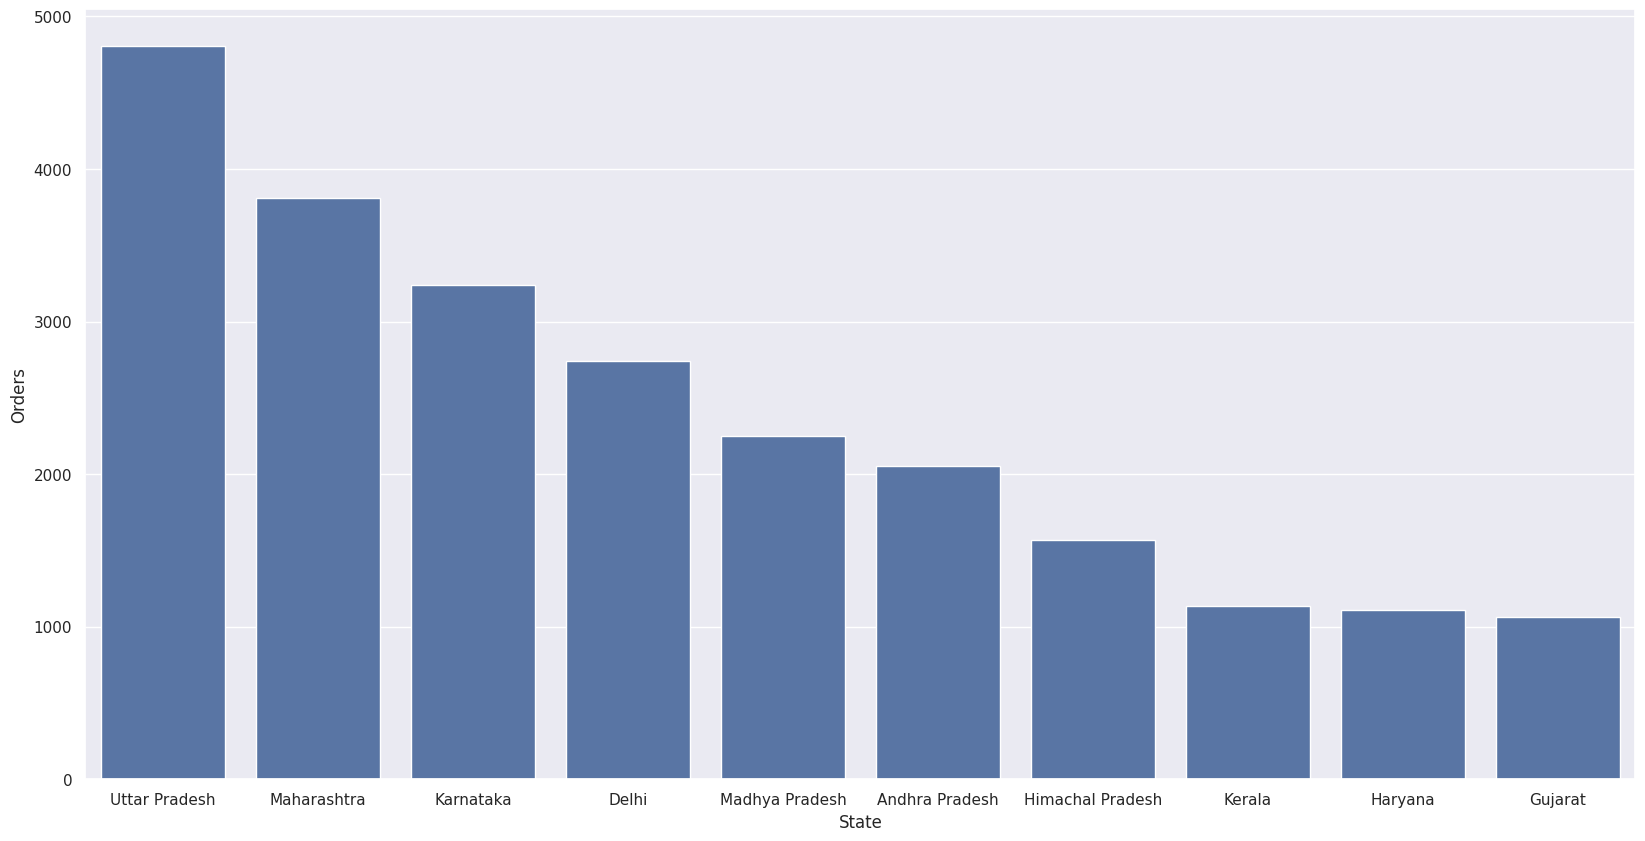

In [ ]:
sales_age = a.groupby(['State'],as_index = False)['Orders'].sum().sort_values(by = 'Orders', ascending=False).head(10)
sns.set(rc={'figure.figsize': (20,10)})
sns.barplot(x = 'State', y = 'Orders', data = sales_age)

**From the above graphs, we can see that most of the Orders and Total_Sales/Amount are from U.P., Maharashtra, Karnataka respectively.**

**Marital_Status**

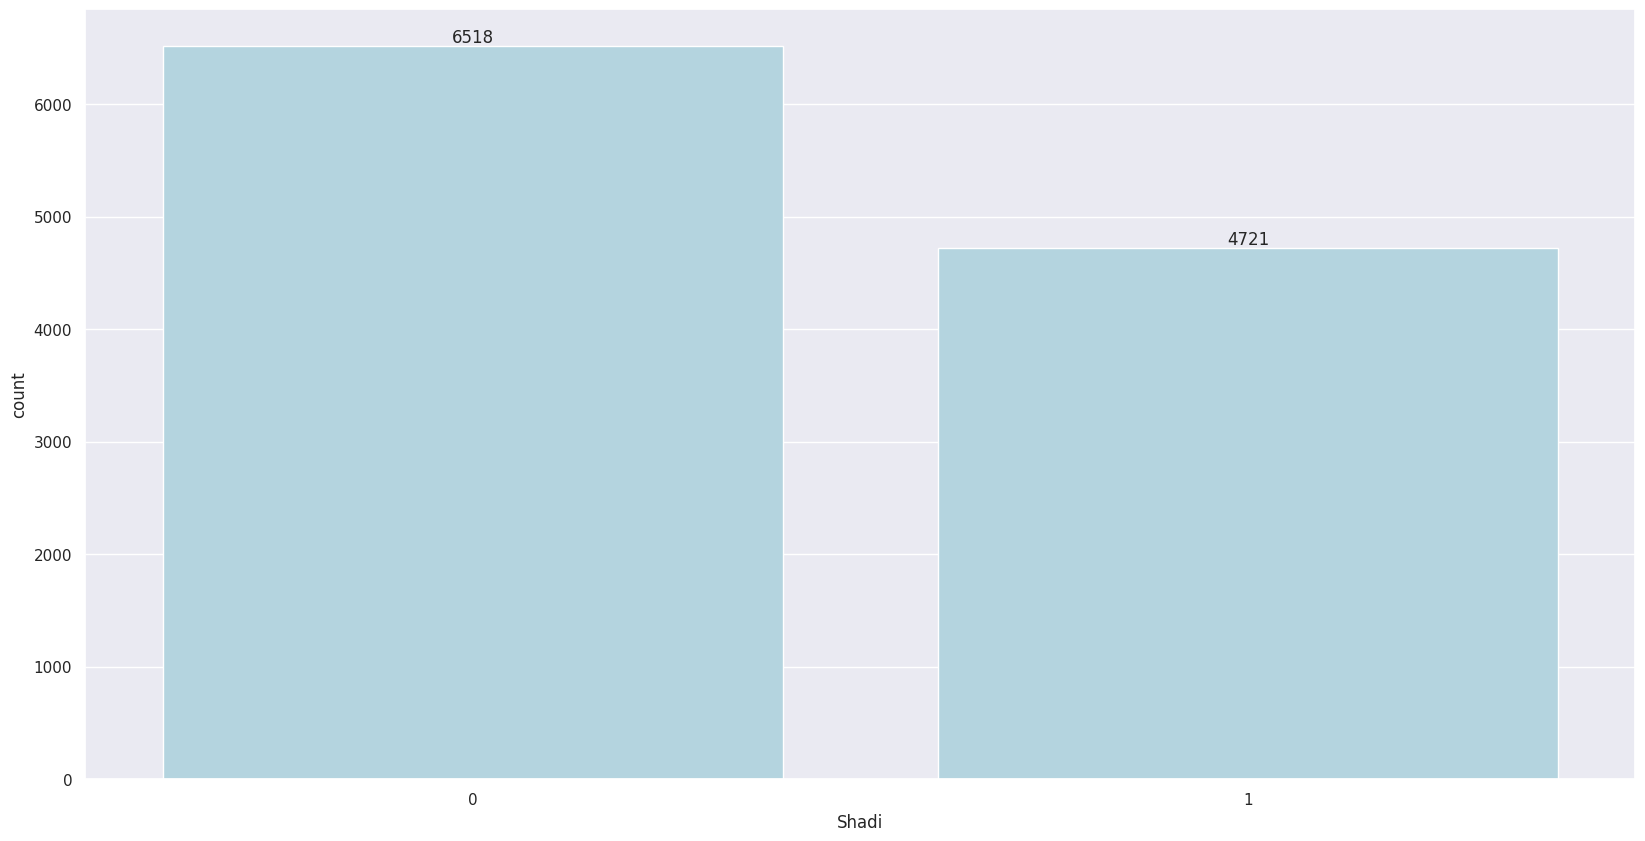

In [ ]:
ac = sns.countplot(data = a, x = 'Shadi', color= 'lightblue')
sns.set(rc = {'figure.figsize':(2,5)})
for bars in ac.containers:
  ac.bar_label(bars)

<Axes: xlabel='Shadi', ylabel='Amount'>

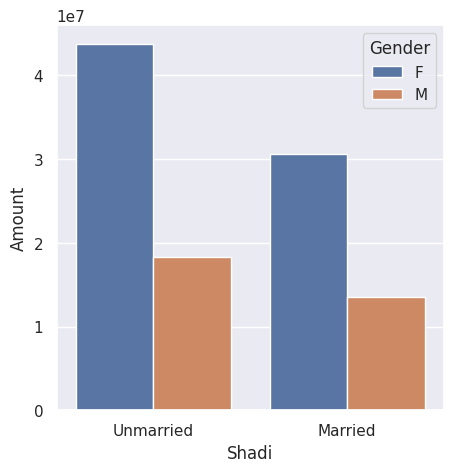

In [ ]:
a['Shadi'] = a['Shadi'].map({0 : "Unmarried", 1 : 'Married'})

sales_age = a.groupby(['Shadi','Gender'],as_index=False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.set(rc = {'figure.figsize':(5,5)})
sns.barplot(x = 'Shadi', y = 'Amount', hue = 'Gender',data = sales_age)

**From the above graphs, we can see that most of the buyiers are married (Women) and they have high purchasing power.**

**Occupation**

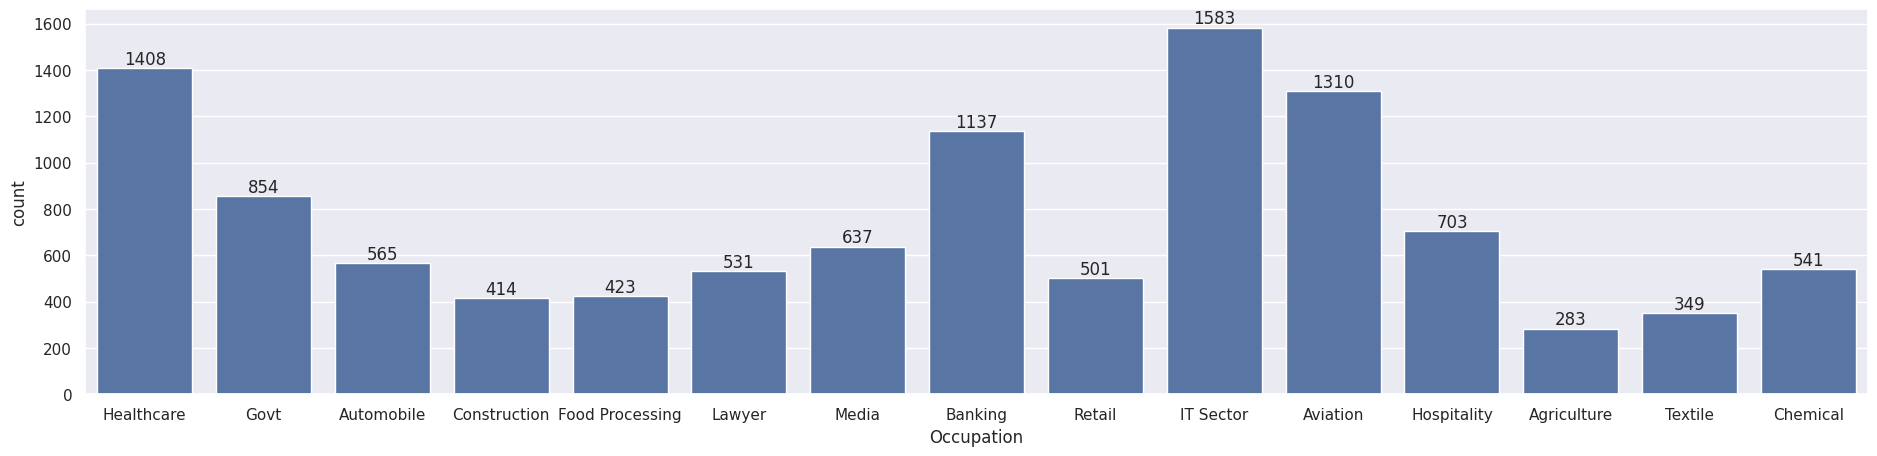

In [ ]:
sns.set(rc = {'figure.figsize':(23,5)})
ax = sns.countplot(data = a, x = 'Occupation')
for bars in ax.containers:
  ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

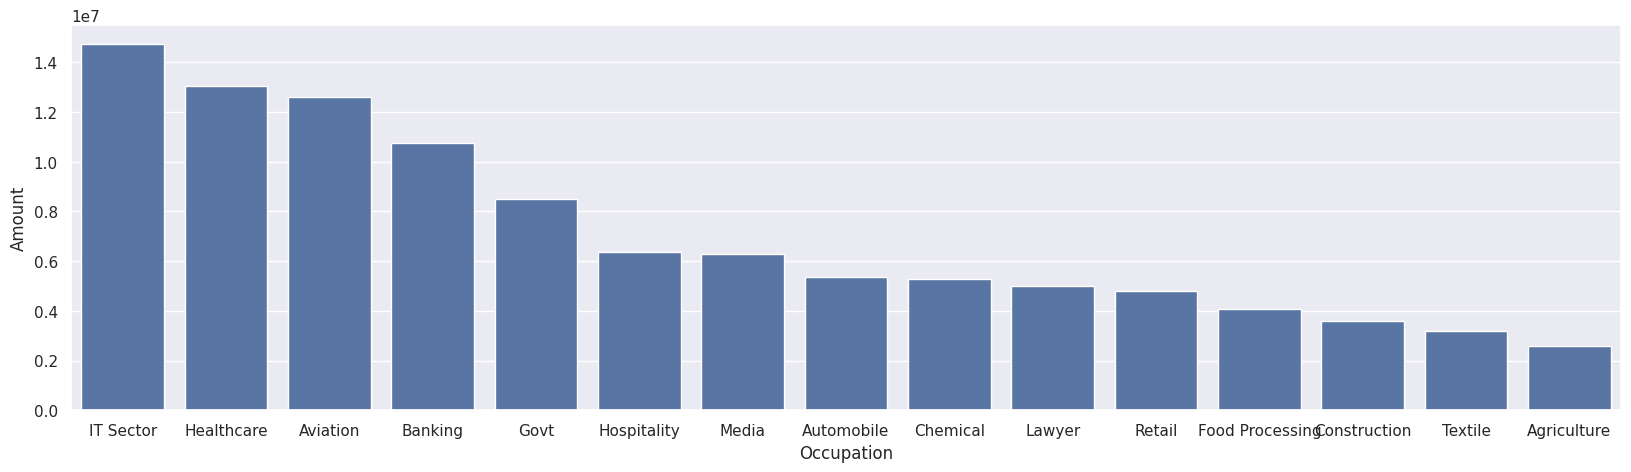

In [ ]:
sales_states = a.groupby(['Occupation'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.set(rc = {'figure.figsize':(20,5)})
sns.barplot(x = 'Occupation', y = 'Amount', data = sales_states)

**From the above graph, we can see that most of the buyers are working in IT Sector, Healthcare, Aviation.**

**Product Category**

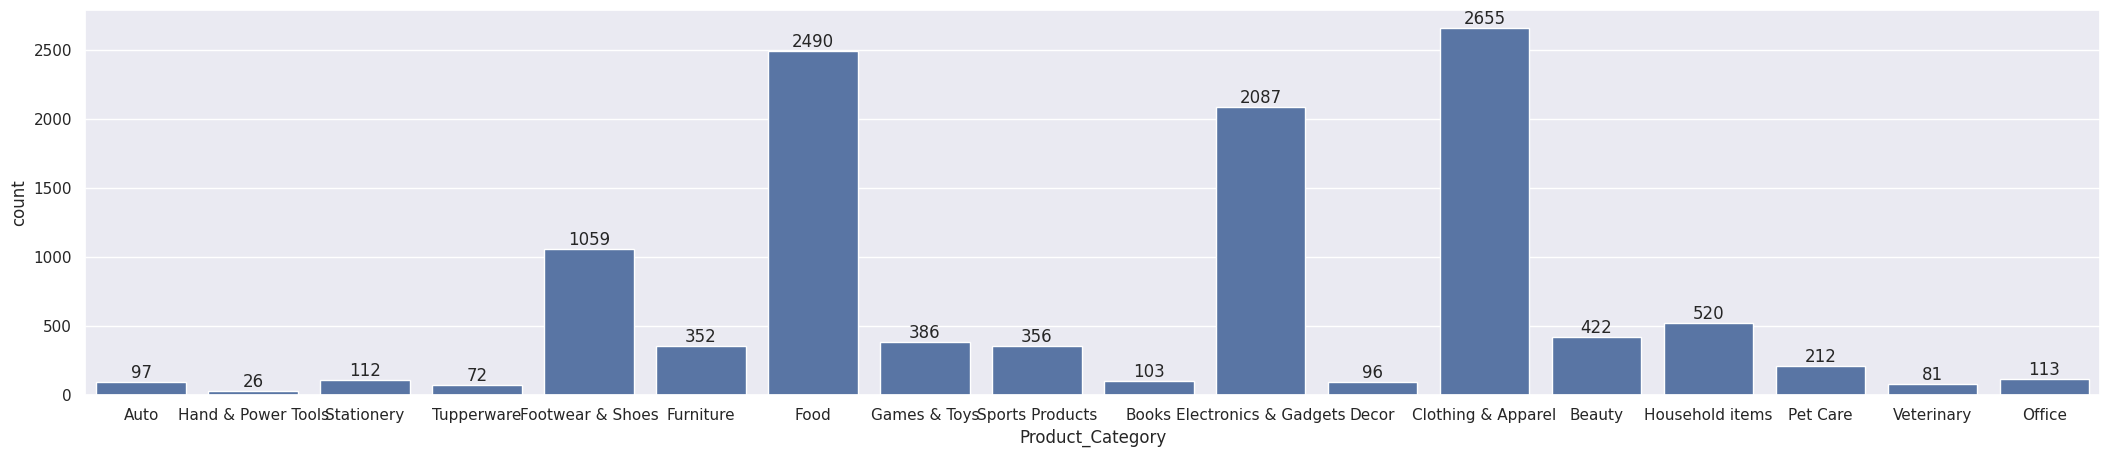

In [ ]:
sns.set(rc = {'figure.figsize':(26,5)})
ax = sns.countplot(data = a, x = 'Product_Category')
for bars in ax.containers:
  ax.bar_label(bars)


<Axes: xlabel='Product_Category', ylabel='Amount'>

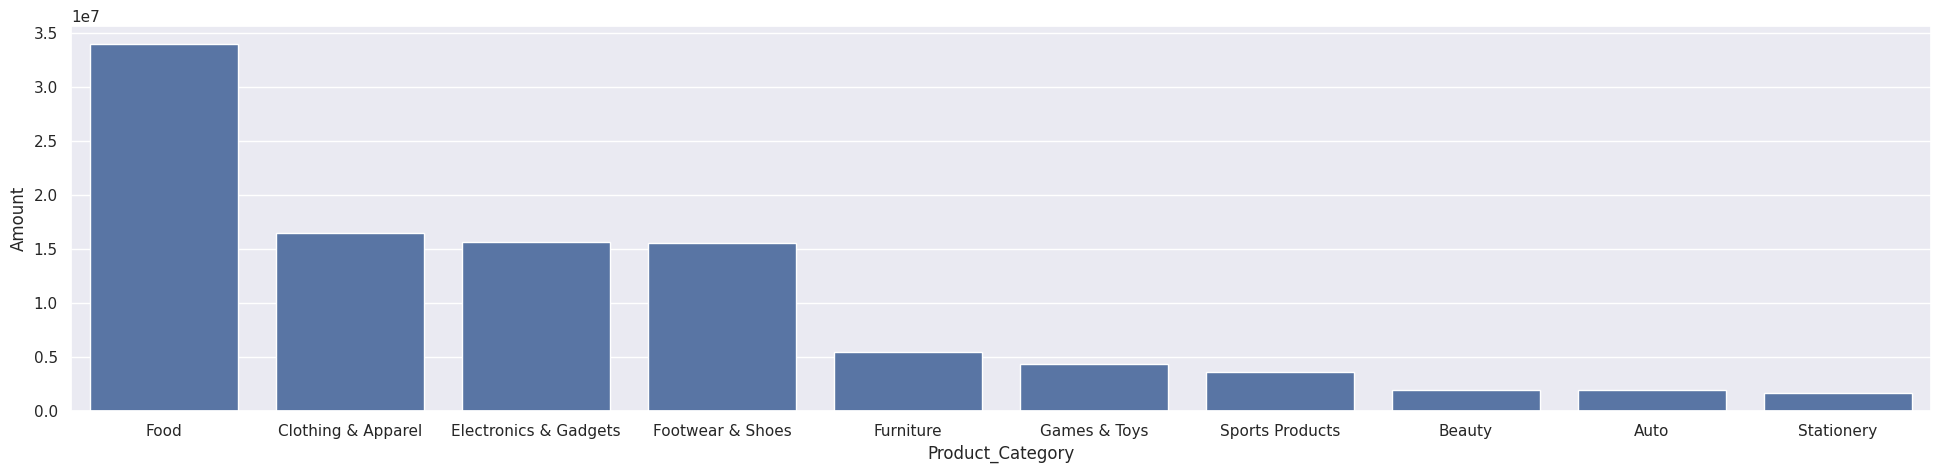

In [ ]:
sales_age = a.groupby(['Product_Category'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False).head(10)
sns.set(rc ={'figure.figsize': (24,5)})
sns.barplot(x = 'Product_Category', y = 'Amount', data = sales_age)

**From the above graph, we can see that most of the sold product are from the Food, colthing and Electronic Category.**

<Axes: xlabel='Product_ID', ylabel='Orders'>

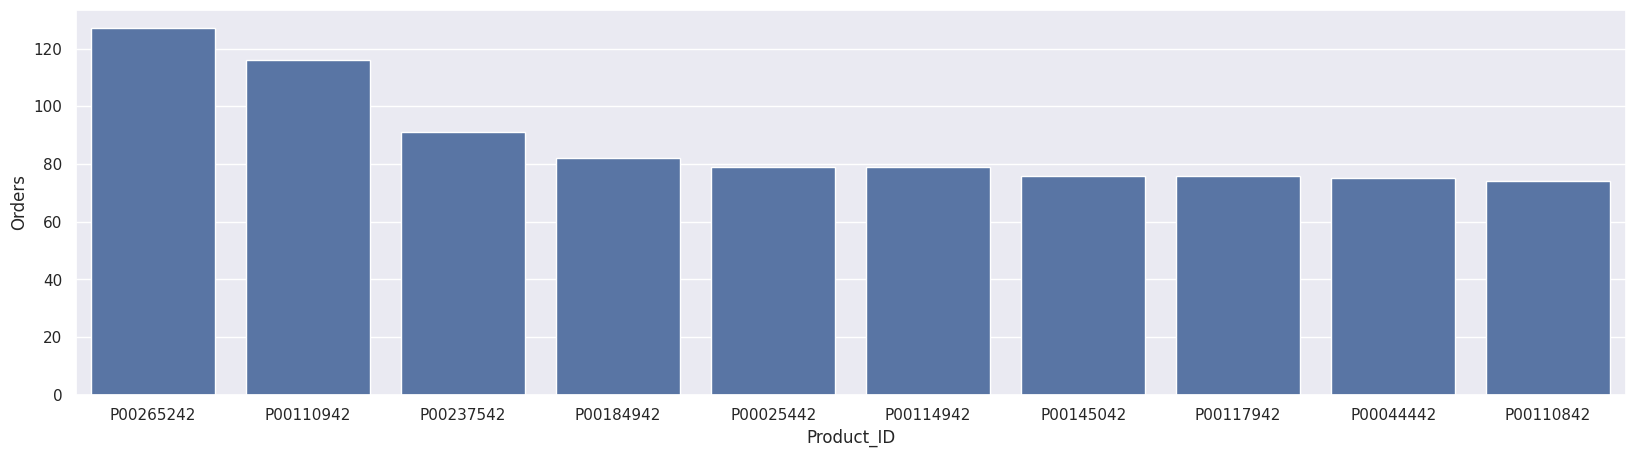

In [ ]:
sales_s = a.groupby(['Product_ID'],as_index = False)['Orders'].sum().sort_values(by = 'Orders', ascending= False).head(10)
sns.set(rc = {'figure.figsize' : (20,5)})
sns.barplot(x = 'Product_ID', y = 'Orders', data = sales_s)

**Top 10 most sold product**

<Axes: xlabel='Product_ID'>

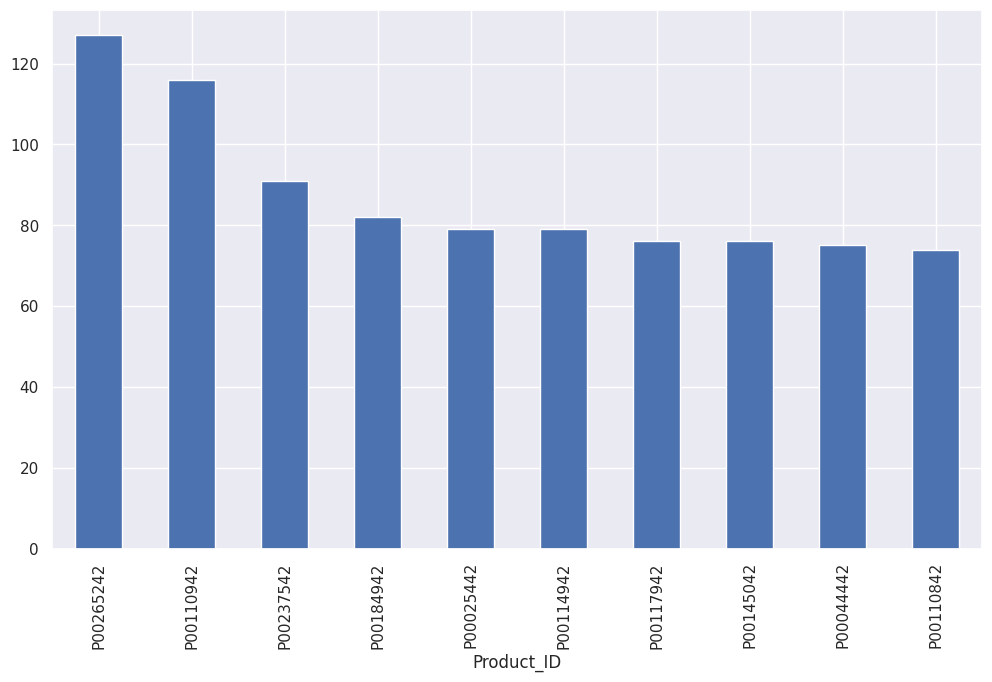

In [ ]:
fig1, ax1 = plt.subplots(figsize =(12,7))
a.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values( ascending = False).plot(kind = 'bar')

**Conclusion**

**Married women Age Group of 26 - 35 from UP, Marashtra, Karnataka working in IT, Healthcare and Aviation are most likely to buy products from Food, Clothing and Electronic category
Thankyou**.